In [1]:
# from google.colab import files
# uploaded = files.upload()

In [2]:
# !ls

In [3]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

if device == "cuda":
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [4]:
import os
import csv
import time
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

def normalize_text(text):
    replacements = {
        "’": "'",
        "‘": "'",
        "“": '"',
        "”": '"',
        "—": "-",
        "–": "-",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def load_and_preprocess(path):
    raw = Path(path).read_text(encoding="utf-8", errors="ignore")
    raw = normalize_text(raw)

    cleaned_lines = []

    for line in raw.splitlines():
        stripped = line.strip()

        # Remove sonnet number lines like "1", "2", ..., "154"
        if stripped.isdigit():
            continue

        # Preserve line breaks, but avoid too many blank lines
        if stripped == "":
            if cleaned_lines and cleaned_lines[-1] != "":
                cleaned_lines.append("")
            continue

        cleaned_lines.append(stripped.lower())

    text = "\n".join(cleaned_lines).strip() + "\n"
    return text


text = load_and_preprocess("shakespeare.txt")

chars = sorted(set(text))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

encoded = [stoi[ch] for ch in text]

print("Total characters after preprocessing:", len(text))
print("Vocabulary size:", len(chars))
print("First 500 characters:")
print(text[:500])

Using device: cuda
GPU: Tesla T4
Total characters after preprocessing: 93827
Vocabulary size: 38
First 500 characters:
from fairest creatures we desire increase,
that thereby beauty's rose might never die,
but as the riper should by time decease,
his tender heir might bear his memory:
but thou contracted to thine own bright eyes,
feed'st thy light's flame with self-substantial fuel,
making a famine where abundance lies,
thy self thy foe, to thy sweet self too cruel:
thou that art now the world's fresh ornament,
and only herald to the gaudy spring,
within thine own bud buriest thy content,
and tender churl mak'st


In [5]:
class CharSequenceDataset(Dataset):
    def __init__(self, encoded_text, seq_len=40, stride=3):
        self.x = []
        self.y = []

        for start in range(0, len(encoded_text) - seq_len, stride):
            self.x.append(encoded_text[start:start + seq_len])
            self.y.append(encoded_text[start + 1:start + seq_len + 1])

        self.x = torch.tensor(self.x, dtype=torch.long)
        self.y = torch.tensor(self.y, dtype=torch.long)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


SEQ_LEN = 40
STRIDE = 3
BATCH_SIZE = 128

dataset = CharSequenceDataset(encoded, seq_len=SEQ_LEN, stride=STRIDE)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)

print("Sequence length:", SEQ_LEN)
print("Stride:", STRIDE)
print("Number of training sequences:", len(dataset))

Sequence length: 40
Stride: 3
Number of training sequences: 31263


In [6]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_size=128, num_layers=1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)
        out, hidden = self.lstm(emb, hidden)
        logits = self.fc(out)
        return logits, hidden


VOCAB_SIZE = len(chars)
EMBEDDING_DIM = 64
HIDDEN_SIZE = 128
NUM_LAYERS = 1

model = CharLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

print(model)

CharLSTM(
  (embedding): Embedding(38, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=38, bias=True)
)


In [7]:
def train_model(model, loader, optimizer, criterion, epochs=1):
    training_log = []
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_tokens = 0

        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            logits, _ = model(batch_x)

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                batch_y.reshape(-1)
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            num_tokens = batch_y.numel()
            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

        avg_loss = total_loss / total_tokens
        elapsed = time.time() - start_time

        training_log.append((epoch, avg_loss, elapsed))

        print(f"Epoch {epoch:03d} | loss = {avg_loss:.4f} | elapsed = {elapsed:.1f}s")

    return training_log


training_log = train_model(
    model=model,
    loader=loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=1,
)

Epoch 001 | loss = 2.1351 | elapsed = 2.1s


In [8]:
EPOCHS = 30

training_log = train_model(
    model=model,
    loader=loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
)

Epoch 001 | loss = 1.6829 | elapsed = 0.8s
Epoch 002 | loss = 1.5504 | elapsed = 1.7s
Epoch 003 | loss = 1.4698 | elapsed = 2.5s
Epoch 004 | loss = 1.4106 | elapsed = 3.3s
Epoch 005 | loss = 1.3613 | elapsed = 4.2s
Epoch 006 | loss = 1.3183 | elapsed = 5.0s
Epoch 007 | loss = 1.2791 | elapsed = 5.8s
Epoch 008 | loss = 1.2444 | elapsed = 6.7s
Epoch 009 | loss = 1.2120 | elapsed = 7.5s
Epoch 010 | loss = 1.1832 | elapsed = 8.3s
Epoch 011 | loss = 1.1578 | elapsed = 9.2s
Epoch 012 | loss = 1.1338 | elapsed = 10.2s
Epoch 013 | loss = 1.1138 | elapsed = 11.2s
Epoch 014 | loss = 1.0942 | elapsed = 12.2s
Epoch 015 | loss = 1.0778 | elapsed = 13.1s
Epoch 016 | loss = 1.0619 | elapsed = 13.9s
Epoch 017 | loss = 1.0482 | elapsed = 14.8s
Epoch 018 | loss = 1.0356 | elapsed = 15.6s
Epoch 019 | loss = 1.0246 | elapsed = 16.4s
Epoch 020 | loss = 1.0133 | elapsed = 17.2s
Epoch 021 | loss = 1.0043 | elapsed = 18.5s
Epoch 022 | loss = 0.9955 | elapsed = 19.5s
Epoch 023 | loss = 0.9882 | elapsed = 20.4s

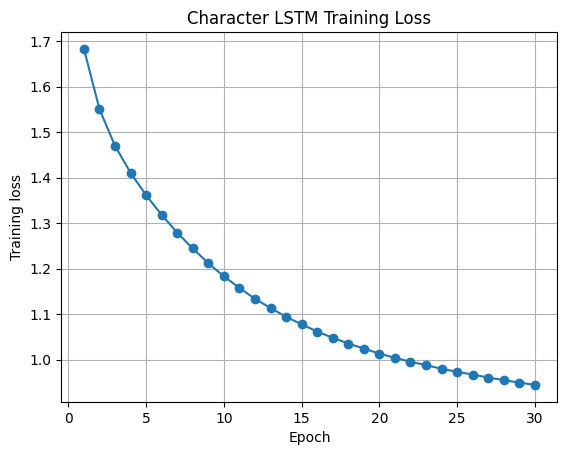

Final training loss: 0.9446137358801182
Total runtime seconds: 27.586889266967773


In [9]:
epochs = [row[0] for row in training_log]
losses = [row[1] for row in training_log]

plt.figure()
plt.plot(epochs, losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Character LSTM Training Loss")
plt.grid(True)
plt.show()

final_loss = losses[-1]
total_runtime = training_log[-1][2]

print("Final training loss:", final_loss)
print("Total runtime seconds:", total_runtime)

In [14]:
@torch.no_grad()
def generate_text_clean(
    model,
    seed_text,
    temperature=1.0,
    max_new_chars=2000,
    target_nonempty_lines=14,
):
    model.eval()

    seed_text = normalize_text(seed_text.lower())
    generated = seed_text
    safe_seed = "".join(ch if ch in stoi else " " for ch in seed_text)

    hidden = None

    for ch in safe_seed[:-1]:
        x = torch.tensor([[stoi[ch]]], dtype=torch.long).to(device)
        _, hidden = model(x, hidden)

    current_char = safe_seed[-1]

    for _ in range(max_new_chars):
        x = torch.tensor([[stoi[current_char]]], dtype=torch.long).to(device)
        logits, hidden = model(x, hidden)

        logits = logits[0, -1, :] / temperature
        probs = torch.softmax(logits, dim=-1)

        next_idx = torch.multinomial(probs, num_samples=1).item()
        next_char = itos[next_idx]

        generated += next_char
        current_char = next_char

    complete_part = generated.rsplit("\n", 1)[0]
    nonempty_lines = [line for line in complete_part.splitlines() if line.strip()]

    return "\n".join(nonempty_lines[:target_nonempty_lines])

In [15]:
seed_text = "shall i compare thee to a summer's day?\n"

for temp in [1.5, 0.75, 0.25]:
    print("=" * 80)
    print(f"TEMPERATURE {temp}")
    print("=" * 80)
    sample = generate_text_clean(
        model=model,
        seed_text=seed_text,
        temperature=temp,
        max_new_chars=2000,
        target_nonempty_lines=14,
    )
    print(sample)
    print()

TEMPERATURE 1.5
shall i compare thee to a summer's day?
whencind!) by lines (xherfeivil flattered couldst out-liked touches were
that loss of thee true feloun:
that his excheins die,
for those graciously rush disdain:
his pleasuref.
as viewed's ocey,
even account it hearts dost life my soul themselves used cloubsing got? once hourest, farren-(stangels the wair,
whereop to me untracted friezing?
than each i in view.
'trust receing their eyes,
and his physies, when need in made so love say) 'stence, to even i live his spites we when effeek of ill's eye
loight, replet my fail, thou art comfore:
since limbly must i in sun ever dumb,

TEMPERATURE 0.75
shall i compare thee to a summer's day?
shall sum to commotere of receipt with thee to the sharved womb)
that i have sake a sometime more, your shadows is,
being manner metrors were
that thou could beauty rhymush of found.
now senses 'nour strongly knows not for their roses frowns,
and to the world hast thou mayst canker cheater withouting his

In [16]:
os.makedirs("outputs", exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "stoi": stoi,
    "itos": itos,
    "seq_len": SEQ_LEN,
    "stride": STRIDE,
    "hidden_size": HIDDEN_SIZE,
    "embedding_dim": EMBEDDING_DIM,
    "num_layers": NUM_LAYERS,
    "final_loss": final_loss,
    "total_runtime": total_runtime,
}, "outputs/char_lstm_model.pt")

with open("outputs/training_log.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "loss", "elapsed_seconds"])
    writer.writerows(training_log)

samples = {}
for temp in [1.5, 0.75, 0.25]:
    samples[temp] = generate_text(
        model=model,
        seed_text=seed_text,
        temperature=temp,
        max_new_chars=900,
        target_nonempty_lines=14,
    )

    with open(f"outputs/sample_temperature_{temp}.txt", "w") as f:
        f.write(samples[temp])

with open("outputs/report_summary.txt", "w") as f:
    f.write("CSE 151B Homework 3 Report Summary\n")
    f.write("==================================\n\n")
    f.write(f"Total characters after preprocessing: {len(text)}\n")
    f.write(f"Vocabulary size: {len(chars)}\n")
    f.write(f"Number of training sequences: {len(dataset)}\n")
    f.write(f"Sequence length: {SEQ_LEN}\n")
    f.write(f"Stride: {STRIDE}\n")
    f.write(f"Embedding dimension: {EMBEDDING_DIM}\n")
    f.write(f"Hidden size: {HIDDEN_SIZE}\n")
    f.write(f"Number of LSTM layers: {NUM_LAYERS}\n")
    f.write(f"Batch size: {BATCH_SIZE}\n")
    f.write(f"Learning rate: 0.002\n")
    f.write(f"Epochs: {EPOCHS}\n")
    f.write(f"Final training loss: {final_loss:.4f}\n")
    f.write(f"Total runtime seconds: {total_runtime:.1f}\n")
    f.write(f"Device: {device}\n\n")

    for temp in [1.5, 0.75, 0.25]:
        f.write(f"\nTemperature {temp}\n")
        f.write("-" * 40 + "\n")
        f.write(samples[temp])
        f.write("\n\n")

print("Saved files:")
!find outputs -type f

Saved files:
outputs/training_log.csv
outputs/report_summary.txt
outputs/char_lstm_model.pt
outputs/sample_temperature_1.5.txt
outputs/sample_temperature_0.25.txt
outputs/sample_temperature_0.75.txt


In [17]:
!zip -r hw3_code_and_outputs.zip outputs

updating: outputs/ (stored 0%)
updating: outputs/training_log.csv (deflated 47%)
updating: outputs/report_summary.txt (deflated 51%)
updating: outputs/char_lstm_model.pt (deflated 7%)
updating: outputs/sample_temperature_1.5.txt (deflated 41%)
updating: outputs/sample_temperature_0.25.txt (deflated 47%)
updating: outputs/sample_temperature_0.75.txt (deflated 43%)


In [18]:
from google.colab import files
files.download("hw3_code_and_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>